In [1]:
import retinanalysis as ra
import importlib
importlib.reload(ra.mea_pipeline)
importlib.reload(ra.sta)
import os
import gc

Could not connect to DataJoint database: (2003, "Can't connect to MySQL server on '127.0.0.1' ([Errno 111] Connection refused)")


In [2]:
exp_name = '20260415C'
chunk_name = 'chunk3'
datafile_name = ['data026']
str_pkl = os.path.join(ra.settings.QUERY_DIR, f'20260415C/chunk3/kilosort2.5/{exp_name}_{datafile_name[0]}_kilosort2.5.pkl')
pl = ra.MEAPipeline(pkl_file=str_pkl)

Initializing StimBlock for None block None from pickle file
StimBlock loaded from input dict.
Initializing ResponseBlock from pickle file.
ResponseBlock loaded from input dict.
Loading VCD from /run/user/1001/gvfs/smb-share:server=128.95.10.105,share=data/data/sorted/20260415C/data026/kilosort2.5 ...
VCD loaded with 419 cells.

Loading VCD from /run/user/1001/gvfs/smb-share:server=128.95.10.105,share=data/analysis/20260415C/chunk3/kilosort2.5 ...
VCD loaded with 419 cells.

AnalysisChunk loaded from input dict.
MEAPipeline loaded from /run/user/1001/gvfs/smb-share:server=128.95.10.105,share=data/analysis/20260415C/chunk3/kilosort2.5/20260415C_data026_kilosort2.5.pkl


In [3]:
importlib.reload(ra.sta)
importlib.reload(ra.regen)
importlib.reload(ra.stim)

# pl = ra.mea_pipeline.create_mea_pipeline(exp_name, datafile_name, b_load_fd=True, b_load_vcd=True)
# pl.export_to_pkl(f'/Volumes/data-1/analysis/20260415C/chunk3/kilosort2.5/{exp_name}_{datafile_name[0]}_kilosort2.5.pkl')

stim_data, resp_data = ra.sta.get_sta_inputs_for_chunk(
    ra.stim.MEAStimGroup([pl.stim]), ra.MEAResponseGroup([pl.resp]), stride=2
)

Regenerating stimulus for epochs: [0 1 2 3] in block: 5173
Using regeneration function: make_spatial_noise


100%|██████████| 4/4 [00:10<00:00,  2.63s/it]


Regenerated stimulus with keys: ['frames', 'steps', 'canvas_size']


Binning spikes for cells:   0%|          | 0/419 [00:00<?, ?it/s]

Mean frame rate: 59.94 Hz

Block 0: pre_frames=14, binned_spikes shape=(419, 12, 21639)
Total frames: 10789
Cropped binned spikes shape: (419, 12, 21578)


In [4]:
stim_data.shape, resp_data.shape

((4, 10789, 114, 183, 3), (12, 419, 21578))

In [5]:
sd = stim_data[:4]
rd = resp_data[:4]
gc.collect()

46

In [6]:
%%time
stas = ra.sta.compute_stas(sd, rd, depth=30, method='conv', verbose=True, stride=2)

Total data size: 21.8GB, max available: 20.3GB
Recommending 4 splits of compute.


STA compute chunk:   0%|          | 0/4 [00:00<?, ?it/s]

CPU times: user 1min 37s, sys: 55.7 s, total: 2min 33s
Wall time: 40.6 s


In [14]:
ra.sta.torch.cuda.empty_cache()

In [12]:
importlib.reload(ra.sta)

<module 'retinanalysis.preprocessing.sta' from '/home/vyomr/Desktop/gitrepos/retinanalysis/src/retinanalysis/preprocessing/sta.py'>

In [13]:
%%time
stas = ra.sta.compute_stas(sd, rd, depth=30, method='matmul', verbose=True, stride=2)

Total data size: 21.8GB, max available: 20.3GB
Recommending 2 splits of compute.


STA compute chunk:   0%|          | 0/2 [00:00<?, ?it/s]

STA depth:   0%|          | 0/30 [00:00<?, ?it/s]

torch.Size([4, 419, 21578]) torch.Size([4, 21578, 31293])
torch.Size([4, 21578, 31293])
torch.Size([4, 419, 21577]) torch.Size([4, 21578, 31293])
torch.Size([4, 21577, 31293])
torch.Size([4, 419, 21576]) torch.Size([4, 21578, 31293])
torch.Size([4, 21576, 31293])
torch.Size([4, 419, 21575]) torch.Size([4, 21578, 31293])
torch.Size([4, 21575, 31293])
torch.Size([4, 419, 21574]) torch.Size([4, 21578, 31293])
torch.Size([4, 21574, 31293])
torch.Size([4, 419, 21573]) torch.Size([4, 21578, 31293])
torch.Size([4, 21573, 31293])
torch.Size([4, 419, 21572]) torch.Size([4, 21578, 31293])
torch.Size([4, 21572, 31293])
torch.Size([4, 419, 21571]) torch.Size([4, 21578, 31293])
torch.Size([4, 21571, 31293])
torch.Size([4, 419, 21570]) torch.Size([4, 21578, 31293])
torch.Size([4, 21570, 31293])
torch.Size([4, 419, 21569]) torch.Size([4, 21578, 31293])
torch.Size([4, 21569, 31293])
torch.Size([4, 419, 21568]) torch.Size([4, 21578, 31293])
torch.Size([4, 21568, 31293])
torch.Size([4, 419, 21567]) torc

STA depth:   0%|          | 0/30 [00:00<?, ?it/s]

torch.Size([4, 419, 21578]) torch.Size([4, 21578, 31293])
torch.Size([4, 21578, 31293])
torch.Size([4, 419, 21577]) torch.Size([4, 21578, 31293])
torch.Size([4, 21577, 31293])
torch.Size([4, 419, 21576]) torch.Size([4, 21578, 31293])
torch.Size([4, 21576, 31293])
torch.Size([4, 419, 21575]) torch.Size([4, 21578, 31293])
torch.Size([4, 21575, 31293])
torch.Size([4, 419, 21574]) torch.Size([4, 21578, 31293])
torch.Size([4, 21574, 31293])
torch.Size([4, 419, 21573]) torch.Size([4, 21578, 31293])
torch.Size([4, 21573, 31293])
torch.Size([4, 419, 21572]) torch.Size([4, 21578, 31293])
torch.Size([4, 21572, 31293])
torch.Size([4, 419, 21571]) torch.Size([4, 21578, 31293])
torch.Size([4, 21571, 31293])
torch.Size([4, 419, 21570]) torch.Size([4, 21578, 31293])
torch.Size([4, 21570, 31293])
torch.Size([4, 419, 21569]) torch.Size([4, 21578, 31293])
torch.Size([4, 21569, 31293])
torch.Size([4, 419, 21568]) torch.Size([4, 21578, 31293])
torch.Size([4, 21568, 31293])
torch.Size([4, 419, 21567]) torc

In [5]:
pl.resp.cell_ids[100]

np.int64(111)

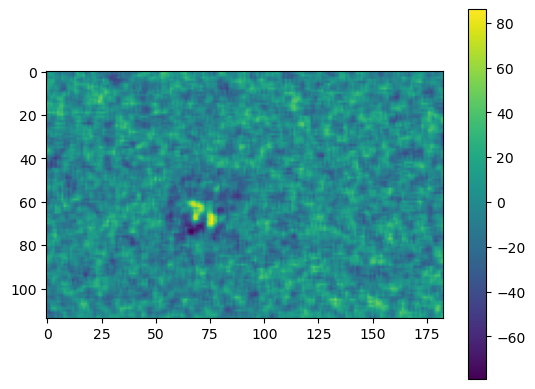

In [18]:
import matplotlib.pyplot as plt
plt.imshow(stas[100, -6, :, :, 0])
plt.colorbar()

In [12]:
import gc
gc.collect()
# Clear GPU memory
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()